In [1]:
from ultralytics import YOLO, SAM
import pickle

In [2]:
# info_path = '../data/nuscenes/nuscenes_data_info.pkl'
# with open(info_path, 'rb') as f:
#     data_info = pickle.load(f)

# scene_idx = 0
# sample_idx = 20
# sweep_idx = -1
# scene = data_info[scene_idx]
# sample = scene['samples'][sample_idx]
# img_path = '.' + sample['cams']['CAM_FRONT']['img_path']

img_path = './test.jpg'

In [3]:
# det_model = YOLO('./ckpts/yolov12l-seg.pt')
det_model = YOLO('./ckpts/yolov12l-seg.engine')
# sam_model = SAM('./ckpts/sam2.1_l.pt')

In [4]:
results = det_model.track(img_path, imgsz=1280, persist=True, retina_masks=True, verbose=False)

Loading ckpts/yolov12l-seg.engine for TensorRT inference...
[06/29/2025-11:05:20] [TRT] [I] Loaded engine size: 66 MiB
[06/29/2025-11:05:20] [TRT] [I] [MS] Running engine with multi stream info
[06/29/2025-11:05:20] [TRT] [I] [MS] Number of aux streams is 1
[06/29/2025-11:05:20] [TRT] [I] [MS] Number of total worker streams is 2
[06/29/2025-11:05:20] [TRT] [I] [MS] The main stream provided by execute/enqueue calls is the first worker stream
[06/29/2025-11:05:20] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +454, now: CPU 1, GPU 509 (MiB)


In [14]:
results[0].masks.data.cpu().numpy().astype(bool).shape

(27, 900, 1600)

In [18]:
(results[0].masks.data[0] > 0).sum()

tensor(40059, device='cuda:0')

In [31]:
import torch
import numpy as np
xy = torch.where(results[0].masks.data[0] > 0)
xy = np.stack((xy[1].cpu().numpy(), xy[0].cpu().numpy()), axis=-1)

In [34]:
results[0].masks.xy[0].shape

(244, 2)

In [32]:
xy

array([[1329,  458],
       [1330,  458],
       [1331,  458],
       ...,
       [1311,  626],
       [1312,  626],
       [1313,  626]])

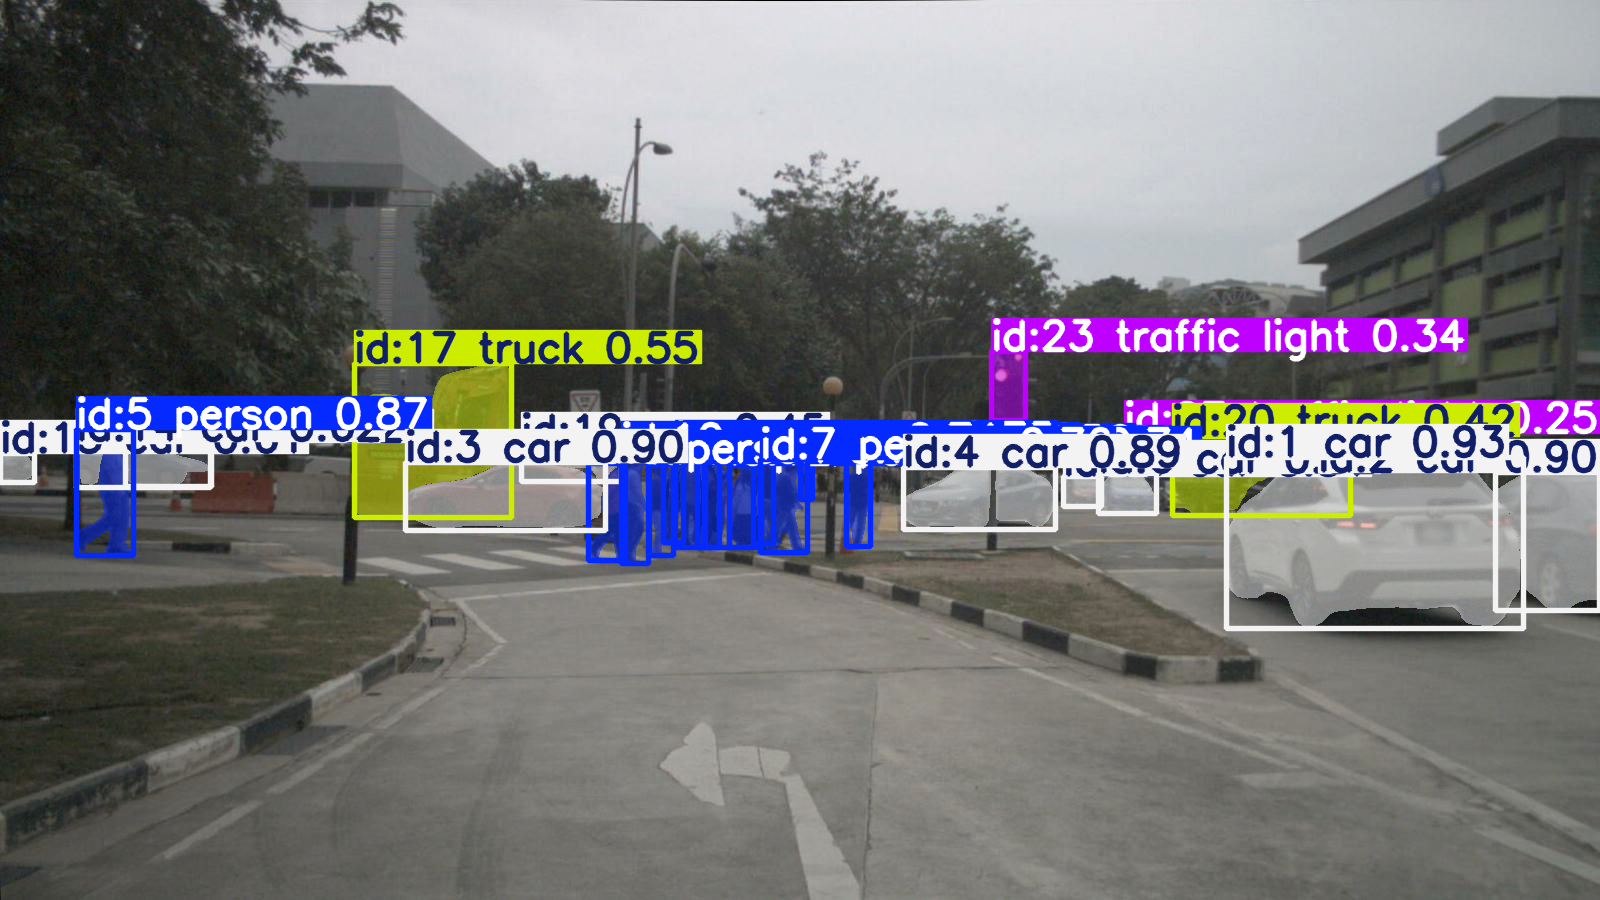

In [5]:
results[0].show()

In [ ]:
det_results = det_model(img_path, retina_masks=True, imgsz=1280)
det_results[0].show(conf=False, labels=True, line_width=2, font_size=2)

In [ ]:
class_ids = det_results[0].boxes.cls.int().tolist()  # Extract class IDs from detection results
if class_ids:
    boxes = det_results[0].boxes.xyxy  # Boxes object for bbox outputs
    sam_results = sam_model(det_results[0].orig_img, bboxes=boxes, verbose=False, save=False)
sam_results[0].show(conf=False, labels=False, line_width=2, font_size=2)